# MatplotlibとSeabornの使い方

可視化は、数字の表をきれいにするための飾りではなく、『いま何が起きているかを一目でつかむ』ための道具です。Matplotlib は土台、Seaborn はその上で統計的な図を手早く描くための補助と考えると分かりやすくなります。

このノートでは、学習の進み具合、2 変数の関係、分布の形、カテゴリごとの差、特徴量同士の関係という 5 つの見方を、図を切り替えながら確かめます。

## 最初に読むまとめ

Matplotlib は、データをグラフとして描くための基本ライブラリです。最初は難しく見えますが、やっていることはかなり単純で、`x 軸に何を置くか`、`y 軸に何を置くか`、`どの種類のグラフで見せるか` を決めて描いているだけです。

特に初学者のうちは、まず `plt.plot()` で折れ線グラフが描けること、`plt.show()` で表示すること、この 2 つを押さえれば十分です。その後で、棒グラフやヒストグラムなどを少しずつ増やしていくと整理しやすくなります。

このあと本編では、実際にいくつかの図を描きながら、`どんな問いにどのグラフを使うか` を順番に見ていきます。以下のまとめは、その本編に入る前の準備として、書き方と考え方を先に整理したものです。

### 1. 最も基本的な書き方

Matplotlib はふつう `plt` という短い名前で読み込みます。これは慣習的な書き方で、多くの教材や実務コードでも同じ形が使われます。

In [4]:
from matplotlib import pyplot as plt
import pandas as pd

実務では、CSV ファイルを `Pandas` で読み込んでから可視化することがよくあります。たとえば `data.csv` というファイルに `day` と `temperature` という列が入っているなら、`df = pd.read_csv("data.csv")` のように読み込めます。

ただし、このノートブックには実際の `data.csv` ファイルを置いていないため、上のコードを実行するとファイルが見つからずエラーになります。ここでは同じ形の表をその場で作って、CSV を読み込んだ後と同じ状態からグラフを描きます。

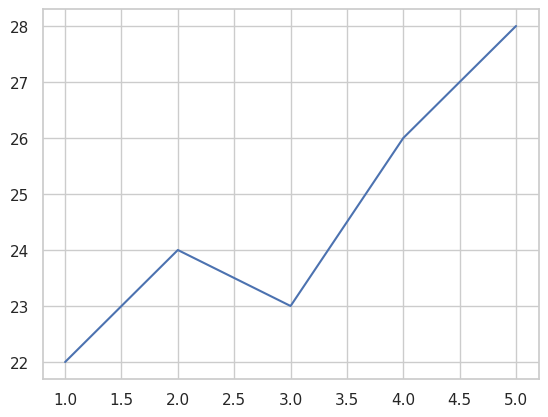

In [5]:
df = pd.DataFrame({
    "day": [1, 2, 3, 4, 5],
    "temperature": [22, 24, 23, 26, 28],
})

x = df["day"]
y = df["temperature"]

plt.plot(x, y)
plt.show()


ここで大事なのは、`x` に横軸、`y` に縦軸へ置きたいデータを入れていることです。CSV から読んだ場合でも、その場で DataFrame を作った場合でも、`df["day"]` のように列を取り出して描く流れは同じです。

また、`plt.show()` は「ここまで作った図を表示する」という合図です。ノートブック環境では省略しても表示されることがありますが、明示的に書いておく方が処理の区切りが分かりやすく、初学者にはおすすめです。

### 2. グラフの種類を変える

同じ `x` と `y` でも、グラフの種類を変えると見えるものが変わります。折れ線グラフは変化の流れ、棒グラフは大小の比較、ヒストグラムは分布、箱ひげ図はばらつきと外れ値を見るのに向いています。

In [ ]:
plt.figure()
plt.bar(x, y)

In [ ]:
plt.figure()
plt.hist(y, bins=5)

In [ ]:
plt.figure()
plt.boxplot(y)

つまり、コードの違いは『何を見たいか』の違いです。まず問いを決めてからグラフを選ぶと、可視化が暗記ではなく理解で進められます。

特に初学者が混乱しやすいのは、同じデータでも図を変えると見え方が大きく変わることです。これは「どれが正しいか」の違いではなく、「どの角度から見るか」の違いです。時間の流れを見たいなら折れ線、ばらつきを見たいならヒストグラムや箱ひげ図、関係を見たいなら散布図、というように目的と結びつけて覚えるのが近道です。

### 3. よく使うグラフの早見表

最初は全部を覚える必要はありませんが、よく出てくるものを次のように整理しておくと便利です。大事なのは、関数名そのものより「この図は何を読むための図か」を結びつけることです。

| グラフの種類 | 関数名 | 使う場面 |
| --- | --- | --- |
| 折れ線グラフ | `plt.plot(x, y)` | 時系列や連続した変化を見る |
| 散布図 | `plt.scatter(x, y)` | 2 つの変数の関係を見る |
| 棒グラフ | `plt.bar(x, y)` | カテゴリごとの大小を比べる |
| 横棒グラフ | `plt.barh(x, y)` | ラベルが長い比較に向く |
| ヒストグラム | `plt.hist(data, bins=10)` | 分布の形やばらつきを見る |
| 箱ひげ図 | `plt.boxplot(data)` | ばらつきや外れ値を見る |
| 円グラフ | `plt.pie(values, labels=labels)` | 割合や構成比を見る |
| エラーバー付きグラフ | `plt.errorbar(x, y, yerr=err)` | 誤差込みのデータを示す |
| 面グラフ | `plt.fill_between(x, y1, y2)` | 範囲や累積量を見る |
| ヒートマップ風の表示 | `plt.imshow(matrix, cmap="viridis")` | 2 次元の値を色で見る |

このノートで最初に確実に押さえたいのは、`plot`、`scatter`、`hist`、`boxplot` です。ここが分かると、多くの可視化の入り口を押さえたことになります。

一方で、円グラフや 3 次元の図のように、存在は知っておけばよいが最初から多用しなくてよいものもあります。まずは「変化」「関係」「分布」「比較」という 4 つに対応する基本図を使い分けられることを目標にするのが現実的です。

### 4. `fig` と `ax` を分けて書く方法

実際には、タイトルを付けたり、複数のグラフを並べたりすることが多いので、`fig` と `ax` を明示的に作る書き方がよく使われます。

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, y)
ax.set_title("Daily Temperature")
ax.set_xlabel("Day")
ax.set_ylabel("Temperature")

plt.show()

`fig` は図全体、`ax` はその中の 1 つのグラフ領域です。少し長く見えますが、構造がはっきりするので、初学者にとってもむしろ読みやすい書き方です。

このあと本編で出てくるコードも、この `fig, ax = plt.subplots()` を土台にして進みます。したがって、ここで `fig` がキャンバス、`ax` が実際に線や点を描く場所だと分かっていると、後続のセルがかなり読みやすくなります。

### 5. パラメータで見た目を整える

グラフは、描くだけでなく読みやすく整えることも大切です。線の色や形、点の印、凡例などは `plot()` の引数や補助メソッドで調整できます。

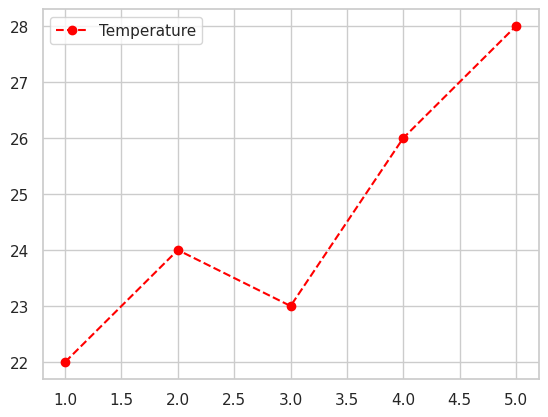

In [7]:
plt.figure()
plt.plot(x, y, color="red", linestyle="--", marker="o", label="Temperature")
plt.legend()
plt.show()

- `color="red"`: 線の色を赤にする
- `linestyle="--"`: 線を破線にする
- `marker="o"`: 各点を丸印で示す
- `label="Temperature"`: 凡例に表示する名前を付ける

見た目の調整は飾りではなく、グラフを読み間違えにくくするための工夫です。たとえば点を入れると「どこに観測値があるか」が分かりやすくなり、凡例を付けると複数系列を並べたときに混乱しにくくなります。色や線種は好みで変えるのではなく、情報を区別しやすくするために使うと考えるのが大切です。

### 6. まずはここだけ覚える

最初の段階では、次の流れだけ理解できれば十分です。

1. `Pandas` で列を取り出す
2. `x` と `y` を決める
3. `plt.plot()` などで描く
4. `plt.show()` で表示する
5. 必要ならタイトルやラベルを付ける

この流れが分かれば、そのあとに出てくる Seaborn や複雑な図も『より便利な書き方』として受け入れやすくなります。

ここまでを踏まえて、この先の本編では「何を見たい図なのか」を先に決め、その問いに合ったグラフを選ぶ形で進みます。つまり、ここで書き方の基本を押さえたうえで、本編では読み取り方と使い分けへ進む構成です。

## まずは『何を見たい図なのか』を決める

可視化で迷いやすいのは、描き方より先に目的が曖昧なままコードを書き始めてしまうことです。増減を見たいのか、関係を見たいのか、ばらつきを見たいのか。そこが決まるだけで、選ぶべき図の候補はかなり絞れます。


このノートでは、1 枚ずつ別の問いに答える形で図を見ていきます。

- 学習が進むにつれて損失はどう下がるか
- 勉強時間と点数には関係がありそうか
- データはどんな分布をしているか
- クラスごとのばらつきは違うか
- 特徴量どうしは似た動きをしているか

こうして問いを先に置くと、グラフの種類が『選ぶもの』になって、暗記項目ではなくなります。


## 図の部品を最初に押さえる

`fig` は図全体、`ax` は実際に描画する座標領域です。`plt.subplots()` を使うのは、この 2 つを最初に受け取って、『どの図全体に、どの軸へ描くのか』を明示しやすいからです。

また、ヒストグラムの `bins` は分布をどれだけ細かく区切るか、`hue` は同じ図の中でカテゴリを色分けして比較するかを表します。


## 眺めるポイントを決めてから図を見る

可視化のセルでは、コードそのものより『この図から何を読み取るべきか』を先に意識すると理解しやすくなります。タイトルや軸ラベルは、その図が何を比較しているのかを固定するために付いています。


## 同じデータでも、図を変えると見えるものが変わる

このあと出てくる `alpha`, `marker`, `bins`, `hue`, `annot` などの引数は、飾りではなく読解を助けるための調整です。点を透かせば重なりが見えやすくなり、bin 数を変えれば分布の粗さが変わり、heatmap に数値を書き込めば色の印象だけで判断せずに済みます。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")


最初は折れ線グラフです。時間やエポックに沿った変化を見るときの基本形で、訓練損失や精度の推移を眺める場面にそのままつながります。

In [ ]:
days = np.arange(1, 11)
loss = np.array([1.8, 1.5, 1.3, 1.15, 1.05, 0.96, 0.90, 0.86, 0.82, 0.79])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(days, loss, marker="o", linewidth=2)
ax.set_title("Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
plt.show()


散布図は、2 つの量の関係を疑うときの第一選択です。完全な直線になる必要はなく、右上がり・右下がり・まとまりの有無といった『傾向』を読むのが役目です。

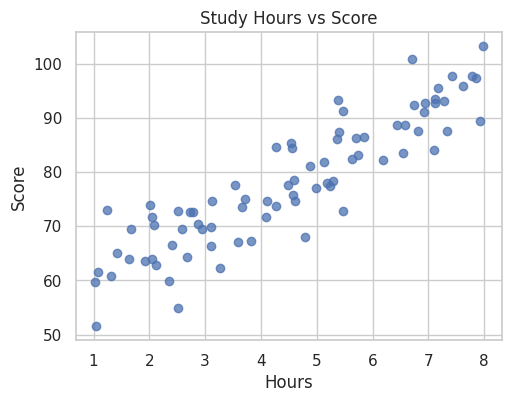

In [2]:
rng = np.random.default_rng(7)
hours = rng.uniform(1, 8, size=80)
score = 52 + hours * 6 + rng.normal(0, 6, size=80)

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.scatter(hours, score, alpha=0.75)
ax.set_title("Study Hours vs Score")
ax.set_xlabel("Hours")
ax.set_ylabel("Score")
plt.show()


ヒストグラムは、平均値だけでは見えない分布の形を見るための図です。裾が長いのか、山が 1 つなのか、ばらつきが大きいのか。`bins` を変えると印象も変わるので、1 枚だけで決めつけない姿勢が大事です。

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
axes[0].hist(score, bins=8, color="#4C78A8", alpha=0.85)
axes[0].set_title("bins=8")
axes[1].hist(score, bins=20, color="#F58518", alpha=0.85)
axes[1].set_title("bins=20")
for ax in axes:
    ax.set_xlabel("Score")
axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()


カテゴリ比較では、各グループの中心とばらつきを同時に見たいことが多くなります。箱ひげ図はそのための図で、中央値と広がりを短時間で比べられます。Seaborn を使うと、この手の図をかなり短いコードで書けます。


In [ ]:
df = pd.DataFrame({
    "class": np.repeat(["A", "B", "C"], repeats=30),
    "score": np.concatenate([
        rng.normal(70, 7, size=30),
        rng.normal(78, 6, size=30),
        rng.normal(74, 8, size=30),
    ])
})

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="class", y="score", ax=ax)
ax.set_title("Score Distribution by Class")
plt.show()


複数系列を 1 枚に重ねるときは、`hue` や凡例で『どれがどれか』を迷わせないことが重要です。ここでは baseline と improved を同じ軸へ置き、改善後の曲線がどこで差を作っているかを見ます。

In [ ]:
df2 = pd.DataFrame({
    "week": np.tile(np.arange(1, 7), 2),
    "accuracy": np.concatenate([
        np.array([0.61, 0.66, 0.70, 0.74, 0.77, 0.79]),
        np.array([0.58, 0.64, 0.69, 0.72, 0.75, 0.78]),
    ]),
    "model": ["baseline"] * 6 + ["improved"] * 6,
})

fig, ax = plt.subplots(figsize=(6, 3.8))
sns.lineplot(data=df2, x="week", y="accuracy", hue="model", marker="o", ax=ax)
ax.set_ylim(0.55, 0.82)
ax.set_title("Validation Accuracy")
plt.show()


相関行列のヒートマップは、特徴量どうしの似た動きを俯瞰するための図です。`annot=True` を付けると数値も直接読めるので、色の濃さだけで誤解しにくくなります。

In [ ]:
feature_df = pd.DataFrame({
    "math": rng.normal(75, 10, size=120),
    "english": rng.normal(73, 9, size=120),
    "science": rng.normal(70, 11, size=120),
    "study_hours": rng.normal(4.5, 1.2, size=120),
})

corr = feature_df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(5, 4.2))
sns.heatmap(corr, annot=True, cmap="Blues", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Matrix")
plt.show()


可視化で一番避けたいのは、『描いたけれど何を見る図か自分で言えない』状態です。図の種類を覚えるより、増減・関係・分布・比較・相関のどれを見たいのかを先に言葉にする方が、実務ではずっと役に立ちます。